In [172]:
import pandas as pd
import numpy as np

In [198]:
from prophet.diagnostics import cross_validation, performance_metrics

In [173]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick 
import seaborn as sns

In [174]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [175]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error

In [176]:
pip install prophet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [177]:
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

In [178]:
df = pd.read_csv(r"C:\Git_test\Digital Native Challenge\Vgsales_Cleaned_Data_test.csv", usecols=['Year', 'Global Sales'])

In [179]:
print(df.dtypes)


Year             object
Global Sales    float64
dtype: object


In [180]:
df['Year'] = df['Year'].astype(str).str[:4]

df['Year'] = pd.to_datetime(df['Year'], format='%Y')

In [181]:
print(df['Year'].dtype)

datetime64[ns]


In [182]:
df.dropna(subset='Year', inplace=True)

In [183]:
df = df.rename(columns={'Year':'ds', 'Global Sales':'y'})

In [184]:
print(df['ds'].dtype)

datetime64[ns]


In [185]:
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

In [186]:
hist_df = df[~df['ds'].dt.year.isin(range(2017, 2021))].copy()

In [187]:
model = Prophet(yearly_seasonality=False, daily_seasonality=False)
model.fit(hist_df)


16:27:46 - cmdstanpy - INFO - Chain [1] start processing
16:27:47 - cmdstanpy - INFO - Chain [1] done processing


In [188]:
future_2017 = pd.DataFrame({'ds': pd.date_range(start='2017-01-01', end='2017-12-31', freq='D')})
forecast_2017 = model.predict(future_2017)

predicted_2017 = forecast_2017['yhat'].sum()

pred_df = pd.DataFrame({
    'year': [2017],
    'y': [predicted_2017],
    'Type': ['Predicted']
})

In [ ]:
hist_yearly = hist_df.groupby(hist_df['ds'].dt.year)['y'].sum().reset_index()
hist_yearly['Type'] = 'Historical'


hist_yearly = hist_yearly.rename(columns={'ds':'year'})
hist_yearly_filtered = hist_yearly[hist_yearly['year'] < 2017]

plot_df = pd.concat([hist_yearly_filtered, pred_df], ignore_index=True)

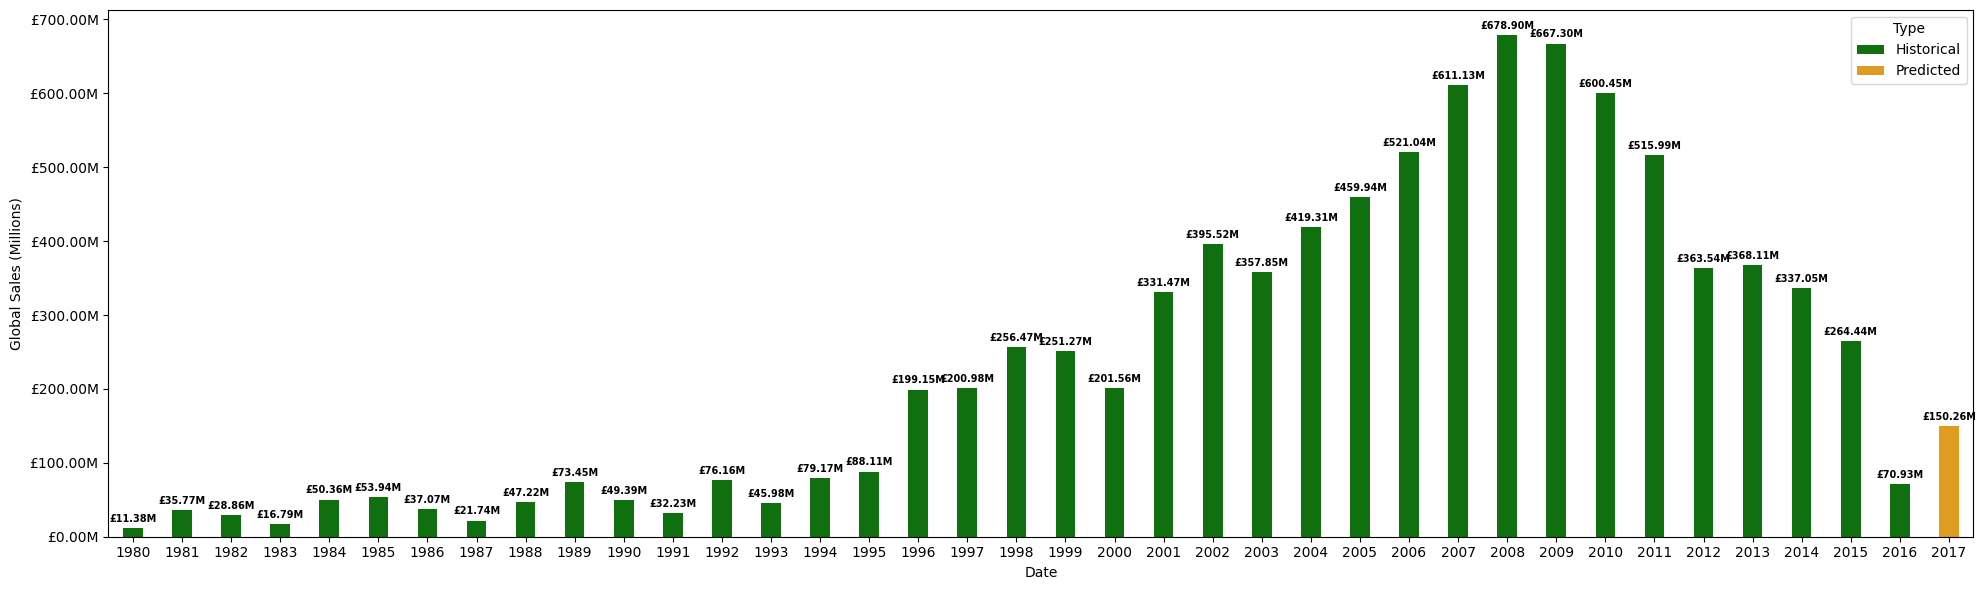

In [190]:
plt.figure(figsize=(20, 6))

ax = sns.barplot(
    x='year',
    y='y',
    data=plot_df,
    hue='Type',                  
    palette={'Historical':'green', 'Predicted':'orange'},
    dodge=False,
    width=0.4
)

ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Global Sales (Millions)", fontsize=10)


for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
        f'£{height:.2f}M',
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=7,
        fontweight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )


ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:.2f}M'))

plt.tight_layout()
plt.show()

In [191]:
model = Prophet(changepoint_prior_scale=0.001,
    seasonality_prior_scale=0.001,
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False,
    growth='linear')
model.fit(train_df)

16:27:51 - cmdstanpy - INFO - Chain [1] start processing
16:27:52 - cmdstanpy - INFO - Chain [1] done processing


In [192]:
future = model.make_future_dataframe(periods=len(test_df))
forecast = model.predict(future)

In [193]:
test_forecast = forecast.iloc[-len(test_df):]

In [194]:
y_true_test = test_df['y'].values
y_pred_test = test_forecast['yhat'].values

y_true_millions = y_true_test / 1_000_000
y_pred_millions = y_pred_test / 1_000_000


print(y_pred_millions[:5])
print(y_true_millions[:5])

[5.37923872e-07 5.37902397e-07 5.37880922e-07 5.37859447e-07
 5.37837972e-07]
[5.e-08 5.e-08 5.e-08 5.e-08 5.e-08]


In [195]:

Pythonrmse = root_mean_squared_error(y_true_millions, y_pred_millions)
mae = mean_absolute_error(y_true_millions, y_pred_millions)
mape = np.mean(np.abs((y_true_millions - y_pred_millions) / y_true_millions)) * 100
naive_error = np.mean(np.abs(np.diff(y_true_millions)))  
mase = mae / naive_error

In [196]:
print("Prophet Accuracy Metrics (Training set):")
print(f"RMSE : {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print("Prophet Accuracy Metrics (Test set):")
print(f"MAPE : {mape:.2f}%")
print(f"MASE : {mase:.2f}")

Prophet Accuracy Metrics (Training set):
RMSE : 0.00
MAE : 0.00
Prophet Accuracy Metrics (Test set):
MAPE : 2300.45%
MASE : 38913.35


In [ ]:
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon='365 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'rmse', 'mae', 'mape']])

  0%|          | 0/68 [00:00<?, ?it/s]

16:27:59 - cmdstanpy - INFO - Chain [1] start processing
16:28:00 - cmdstanpy - INFO - Chain [1] done processing
16:28:01 - cmdstanpy - INFO - Chain [1] start processing
16:28:01 - cmdstanpy - INFO - Chain [1] done processing
16:28:02 - cmdstanpy - INFO - Chain [1] start processing
16:28:02 - cmdstanpy - INFO - Chain [1] done processing
16:28:02 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:28:02 - cmdstanpy - INFO - Chain [1] start processing
16:28:02 - cmdstanpy - INFO - Chain [1] done processing
16:28:03 - cmdstanpy - INFO - Chain [1] start processing
16:28:03 - cmdstanpy - INFO - Chain [1] done processing
16:28:03 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
16:28:03 - cmdstanpy - INFO - Chain [1] start processing
16:28:04 - cmdstanpy - INFO - Chain [1] done processing
16:28:05 - cmdstanpy - INFO - Chain [1] 

    horizon      rmse       mae      mape
0  112 days  1.432375  0.638047  2.407621
1  117 days  1.203850  0.564732  2.194178
2  122 days  1.172169  0.539338  2.158965
3  128 days  1.322243  0.517843  2.180006
4  133 days  2.245376  0.569940  2.235108
5  138 days  2.292998  0.599787  2.321299
6  143 days  2.084076  0.589720  2.341104
7  149 days  1.576224  0.552255  2.339201
8  154 days  1.585724  0.557919  2.345142
9  159 days  1.476705  0.562608  2.397229
10 164 days  1.422010  0.576675  2.328261
11 170 days  1.477756  0.608370  2.288454
12 175 days  1.459056  0.625962  2.327978
13 180 days  1.438275  0.639344  2.488391
14 192 days  1.436489  0.639621  2.476152
15 197 days  1.533999  0.651623  2.465754
16 203 days  1.703721  0.670925  2.464553
17 208 days  1.720032  0.689208  2.468893
18 213 days  1.729019  0.700440  2.508417
19 218 days  1.756351  0.712052  2.504617
20 224 days  1.862708  0.736038  2.524842
21 229 days  1.897518  0.751772  2.525368
22 234 days  1.937425  0.794480  2